In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats

from config import DATA_PROCESSED, OUTPUTS_DIR, OUTPUT_FLOOR
from src.rwa_irb import irb_risk_weight

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "font.size"        : 11,
})

# Load the full dataset with pd_logistic and sa_rwa already computed
df = pd.read_parquet(DATA_PROCESSED / "model_dataset.parquet")
print(f"Loaded {len(df):,} loans")
print(f"Mean annual PD (1yr, horizon-adjusted): {df['pd_logistic_1yr'].mean()*100:.3f}%")

# LGD assumptions to test
# Base case is 0.20 (20%) — this is what we used in weeks 5-12
# We test lower (optimistic) and higher (conservative) assumptions
LGD_ASSUMPTIONS = [0.10, 0.15, 0.20, 0.25]
LGD_LABELS      = ["LGD=10% (Basel floor, para 266)", "LGD=15%", "LGD=20% (base)", "LGD=25%"]

Loaded 4,464,305 loans
Mean annual PD (1yr, horizon-adjusted): 0.620%


In [2]:
# For each LGD assumption, we:
#   1. Recompute IRB risk weight and RWA using pd_logistic_1yr (annual)
#   2. Recompute IRB/SA ratio
#   3. Recompute floor bindingness
#   4. Aggregate by FICO band
#
# The SA RWA does not change — it is LTV-driven and LGD-independent.
# Only the IRB RWA changes with LGD, because the Basel formula
# scales capital requirements linearly with LGD.
#
# If our finding (super-prime is most floor-exposed) holds across
# all four LGD assumptions, it is robust to this parameter choice.

vectorised_irb = np.vectorize(irb_risk_weight)

results = {}   # store band-level summary for each LGD

for lgd, label in zip(LGD_ASSUMPTIONS, LGD_LABELS):

    print(f"\nRunning analysis for {label} ...")

    # Apply IRB formula with this LGD
    irb_rw  = vectorised_irb(df["pd_logistic_1yr"].values, lgd)
    irb_rwa = df["orig_upb"].values * irb_rw

    # Floor ratio and bindingness
    floor_ratio  = np.where(df["sa_rwa"] > 0,
                            irb_rwa / df["sa_rwa"].values,
                            np.nan)
    floor_binds  = (floor_ratio < OUTPUT_FLOOR).astype(int)

    n_binds  = floor_binds.sum()
    pct_binds = n_binds / len(df) * 100
    print(f"  Total floor binds: {n_binds:,} ({pct_binds:.2f}%)")

    # Band-level aggregation
    tmp = df[["fico_band"]].copy()
    tmp["floor_ratio"] = floor_ratio
    tmp["floor_binds"] = floor_binds
    tmp["irb_rwa"]     = irb_rwa

    band = (
        tmp.groupby("fico_band", observed=True)
        .agg(
            loans      = ("floor_ratio", "count"),
            mean_ratio = ("floor_ratio", "mean"),
            n_binds    = ("floor_binds", "sum"),
        )
        .reset_index()
    )
    band["bind_rate_pct"] = band["n_binds"] / band["loans"] * 100
    band["lgd_label"]     = label
    band["lgd"]           = lgd

    results[label] = band

    # Print summary table
    print(f"  {'Band':<25} {'Mean IRB/SA':>12} {'Bind rate':>10}")
    print("  " + "-" * 50)
    for _, row in band.iterrows():
        print(f"  {str(row['fico_band']):<25} "
              f"{row['mean_ratio']:>11.3f}x "
              f"{row['bind_rate_pct']:>9.2f}%")

print("\nAll LGD scenarios complete.")


Running analysis for LGD=10% (Basel floor, para 266) ...


  Total floor binds: 4,371,784 (97.93%)
  Band                       Mean IRB/SA  Bind rate
  --------------------------------------------------
  <620 (subprime)                 0.771x     44.95%
  620–659 (near-prime)            0.644x     67.87%
  660–719 (prime)                 0.426x     95.95%
  720–759 (prime+)                0.275x     99.96%
  760+ (super-prime)              0.172x    100.00%

Running analysis for LGD=15% ...


  Total floor binds: 3,971,941 (88.97%)
  Band                       Mean IRB/SA  Bind rate
  --------------------------------------------------
  <620 (subprime)                 1.157x      6.68%
  620–659 (near-prime)            0.966x     20.53%
  660–719 (prime)                 0.639x     67.99%
  720–759 (prime+)                0.413x     95.73%
  760+ (super-prime)              0.258x     99.92%

Running analysis for LGD=20% (base) ...


  Total floor binds: 3,450,925 (77.30%)
  Band                       Mean IRB/SA  Bind rate
  --------------------------------------------------
  <620 (subprime)                 1.543x      0.84%
  620–659 (near-prime)            1.288x      5.00%
  660–719 (prime)                 0.852x     38.19%
  720–759 (prime+)                0.550x     80.82%
  760+ (super-prime)              0.344x     98.44%

Running analysis for LGD=25% ...


  Total floor binds: 2,923,948 (65.50%)
  Band                       Mean IRB/SA  Bind rate
  --------------------------------------------------
  <620 (subprime)                 1.928x      0.11%
  620–659 (near-prime)            1.609x      1.18%
  660–719 (prime)                 1.065x     19.28%
  720–759 (prime+)                0.688x     61.08%
  760+ (super-prime)              0.430x     93.50%

All LGD scenarios complete.


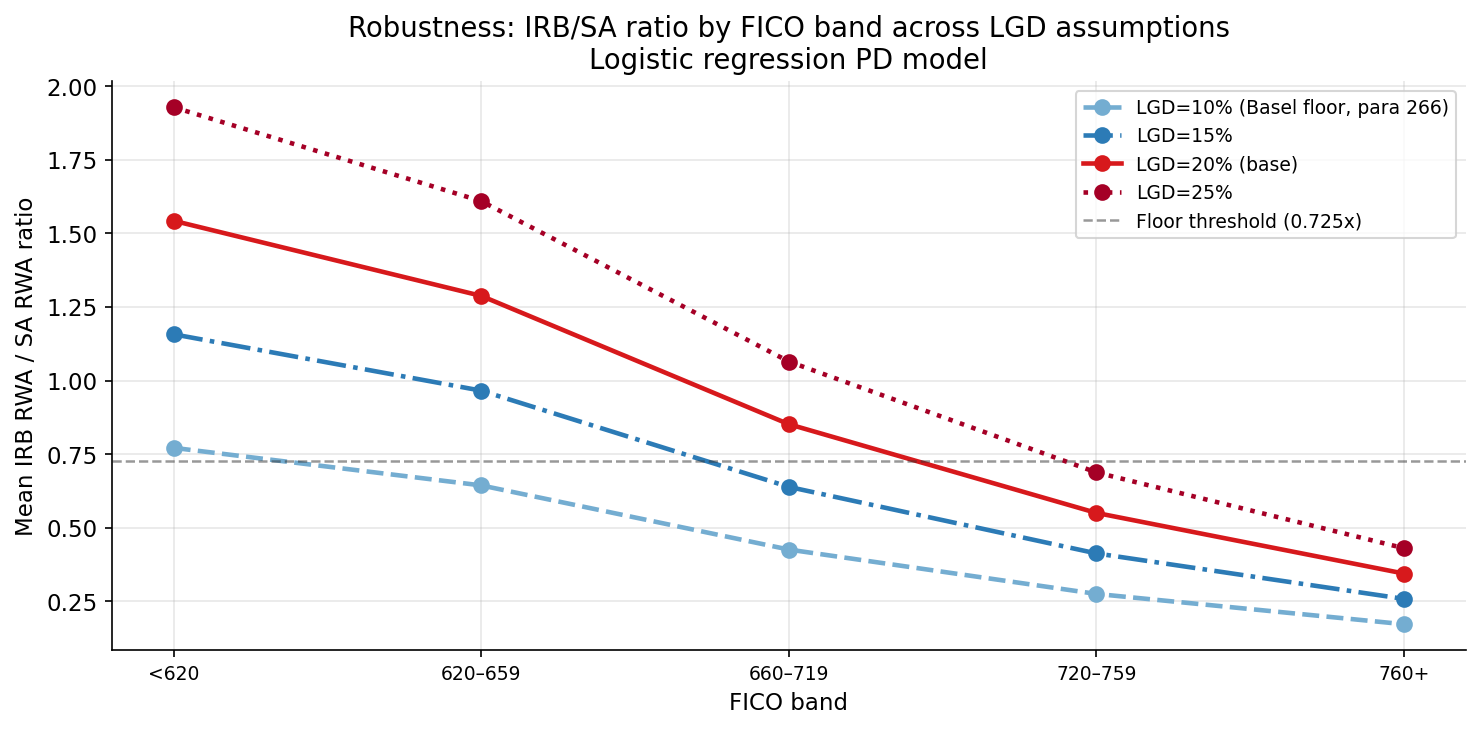

Saved fig14_robustness_ratio_by_lgd.png


In [3]:
# This is the main robustness chart.
# Each line represents one LGD assumption.
# If all four lines slope downward left-to-right, the finding is robust.

fig, ax = plt.subplots(figsize=(10, 5))

colours    = ["#74add1", "#2c7bb6", "#d7191c", "#a50026"]
linestyles = ["--", "-.", "-", ":"]
band_labels = [str(b) for b in df["fico_band"].cat.categories]
x = range(len(band_labels))

for (label, band), colour, ls in zip(results.items(), colours, linestyles):
    ax.plot(
        x,
        band["mean_ratio"].values,
        color=colour,
        linewidth=2.2,
        linestyle=ls,
        marker="o",
        markersize=7,
        label=label,
    )

ax.axhline(
    OUTPUT_FLOOR,
    color="#333333",
    linewidth=1.2,
    linestyle="--",
    alpha=0.5,
    label=f"Floor threshold (0.725x)",
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [b.split(" ")[0] for b in band_labels],
    fontsize=9
)
ax.set_xlabel("FICO band")
ax.set_ylabel("Mean IRB RWA / SA RWA ratio")
ax.set_title(
    "Robustness: IRB/SA ratio by FICO band across LGD assumptions\n"
    "Logistic regression PD model"
)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
path = OUTPUTS_DIR / "fig14_robustness_ratio_by_lgd.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved {path.name}")

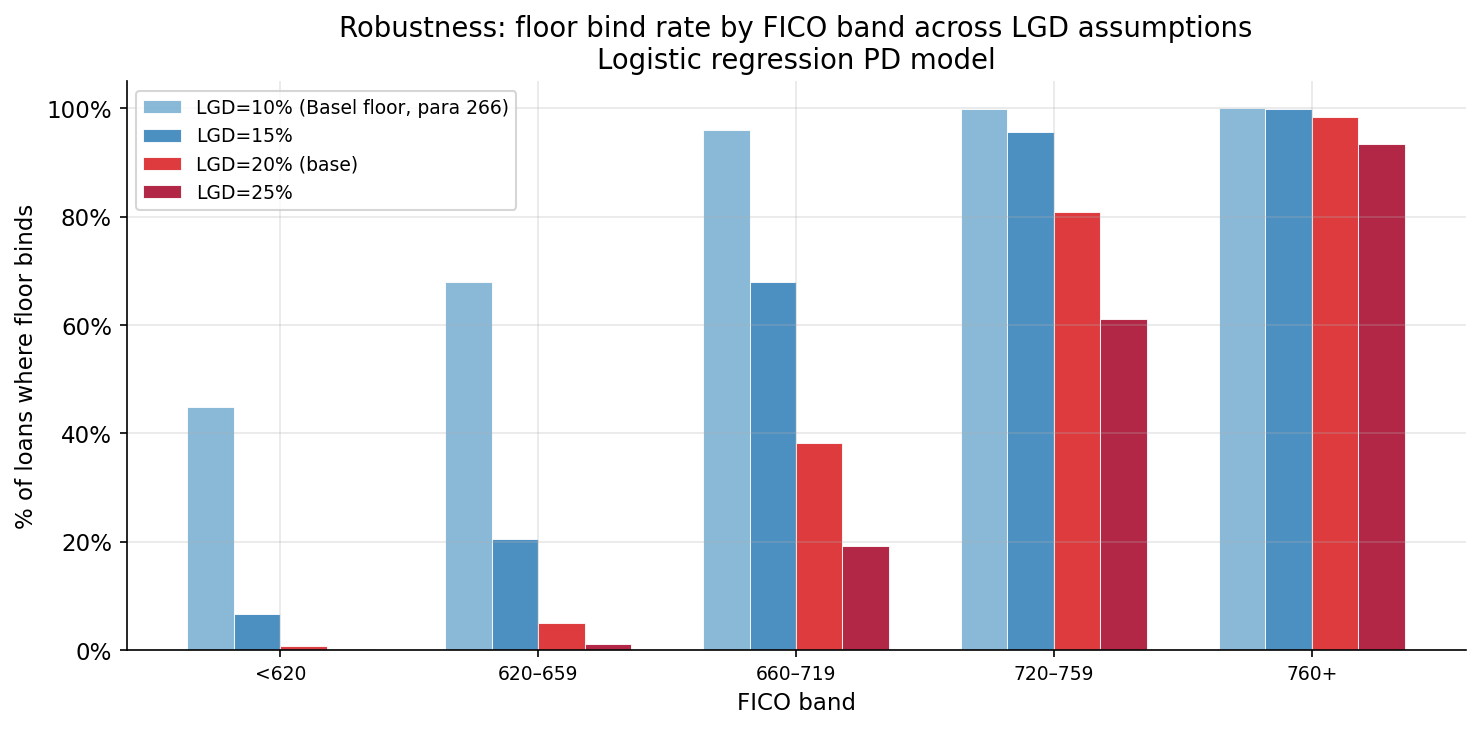

Saved fig15_robustness_bind_rate_by_lgd.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

bar_width = 0.18
n_bands   = len(band_labels)
n_lgds    = len(LGD_ASSUMPTIONS)
x_base    = np.arange(n_bands)

colours = ["#74add1", "#2c7bb6", "#d7191c", "#a50026"]

for i, (label, band) in enumerate(results.items()):
    offset = (i - n_lgds / 2 + 0.5) * bar_width
    bars = ax.bar(
        x_base + offset,
        band["bind_rate_pct"].values,
        width=bar_width,
        color=colours[i],
        alpha=0.85,
        label=label,
        edgecolor="white",
        linewidth=0.5,
    )

ax.set_xticks(x_base)
ax.set_xticklabels(
    [b.split(" ")[0] for b in band_labels],
    fontsize=9
)
ax.set_xlabel("FICO band")
ax.set_ylabel("% of loans where floor binds")
ax.set_title(
    "Robustness: floor bind rate by FICO band across LGD assumptions\n"
    "Logistic regression PD model"
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=9)

plt.tight_layout()
path = OUTPUTS_DIR / "fig15_robustness_bind_rate_by_lgd.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved {path.name}")

In [5]:
# Combine all LGD scenarios into one clean summary table
# This is Table 4 in your dissertation — the robustness table

all_bands = pd.concat(results.values(), ignore_index=True)

# Pivot to wide format: rows = FICO band, columns = LGD scenario
pivot_ratio = all_bands.pivot(
    index="fico_band",
    columns="lgd_label",
    values="mean_ratio"
).round(3)

pivot_binds = all_bands.pivot(
    index="fico_band",
    columns="lgd_label",
    values="bind_rate_pct"
).round(2)

print("Table 4a — Mean IRB/SA ratio by FICO band and LGD assumption:")
print(pivot_ratio.to_string())

print("\nTable 4b — Floor bind rate (%) by FICO band and LGD assumption:")
print(pivot_binds.to_string())

# Save both tables
pivot_ratio.to_csv(OUTPUTS_DIR / "table4a_robustness_ratio.csv")
pivot_binds.to_csv(OUTPUTS_DIR / "table4b_robustness_bind_rate.csv")
print("\nSaved table4a and table4b to outputs/")

Table 4a — Mean IRB/SA ratio by FICO band and LGD assumption:
lgd_label             LGD=10% (Basel floor, para 266)  LGD=15%  LGD=20% (base)  LGD=25%
fico_band                                                                              
<620 (subprime)                                 0.771    1.157           1.543    1.928
620–659 (near-prime)                            0.644    0.966           1.288    1.609
660–719 (prime)                                 0.426    0.639           0.852    1.065
720–759 (prime+)                                0.275    0.413           0.550    0.688
760+ (super-prime)                              0.172    0.258           0.344    0.430

Table 4b — Floor bind rate (%) by FICO band and LGD assumption:
lgd_label             LGD=10% (Basel floor, para 266)  LGD=15%  LGD=20% (base)  LGD=25%
fico_band                                                                              
<620 (subprime)                                 44.95     6.68            0.84   

In [6]:
print("=" * 60)
print("ROBUSTNESS CHECK CONCLUSION")
print("=" * 60)

print("""
LGD sensitivity analysis tests whether the core finding —
that the output floor binds heterogeneously across FICO
segments, with super-prime borrowers most constrained —
is robust to the choice of LGD assumption.

For H1 robustness: the IRB/SA ratio should decrease
monotonically with FICO score under all four LGD assumptions.

For H2 robustness: floor binding should remain concentrated
in the super-prime segment under all four LGD assumptions.
""")

for label, band in results.items():
    ratios = band["mean_ratio"].values
    # Check monotonicity: each ratio should be lower than the previous
    is_monotonic = all(ratios[i] > ratios[i+1]
                       for i in range(len(ratios)-1))
    bind_rates = band["bind_rate_pct"].values

    # Check concentration: only super-prime should have material binds
    # (define material as > 0.5%)
    only_superprime_binds = (
        all(r < 0.5 for r in bind_rates[:-1]) and
        bind_rates[-1] > 0
    )

    print(f"{label}:")
    print(f"  IRB/SA monotonically decreasing : "
          f"{'YES' if is_monotonic else 'NO'}")
    print(f"  Floor binding in super-prime only: "
          f"{'YES' if only_superprime_binds else 'NO — check table'}")
    print(f"  Ratios: {' → '.join([f'{r:.2f}x' for r in ratios])}")
    print()

print("If all scenarios show YES above, the finding is robust.")

ROBUSTNESS CHECK CONCLUSION

LGD sensitivity analysis tests whether the core finding —
that the output floor binds heterogeneously across FICO
segments, with super-prime borrowers most constrained —
is robust to the choice of LGD assumption.

For H1 robustness: the IRB/SA ratio should decrease
monotonically with FICO score under all four LGD assumptions.

For H2 robustness: floor binding should remain concentrated
in the super-prime segment under all four LGD assumptions.

LGD=10% (Basel floor, para 266):
  IRB/SA monotonically decreasing : YES
  Floor binding in super-prime only: NO — check table
  Ratios: 0.77x → 0.64x → 0.43x → 0.28x → 0.17x

LGD=15%:
  IRB/SA monotonically decreasing : YES
  Floor binding in super-prime only: NO — check table
  Ratios: 1.16x → 0.97x → 0.64x → 0.41x → 0.26x

LGD=20% (base):
  IRB/SA monotonically decreasing : YES
  Floor binding in super-prime only: NO — check table
  Ratios: 1.54x → 1.29x → 0.85x → 0.55x → 0.34x

LGD=25%:
  IRB/SA monotonically dec